Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 47)             │        12,079 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,327 (2.08 MB)

 Trainable params: 545,327 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
882/882 ━━━━━━━━━━━━━━━━━━━━ 31s 33ms/step - accuracy: 0.6517 - loss: 1.1845 - val_accuracy: 0.7972 - val_loss: 0.6530
Epoch 2/10
882/882 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - accuracy: 0.7716 - loss: 0.7101 - val_accuracy: 0.8230 - val_loss: 0.5479
Epoch 3/10
882/882 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - accuracy: 0.8001 - loss: 0.6132 - val_accuracy: 0.8326 - val_loss: 0.5035
Epoch 4/10
882/882 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - accuracy: 0.8127 - loss: 0.5595 - val_accuracy: 0.8368 - val_loss: 0.4853
Epoch 5/10
882/882 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - accuracy: 0.8209 - loss: 0.5245 - val_accuracy: 0.8439 - val_loss: 0.4681
Epoch 6/10
882/882 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.8289 - loss: 0.4996 - val_accuracy: 0.8482 - val_loss: 0.4573
Epoch 7/10
882/882 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - accuracy: 0.8330 - loss: 0.4790 - val_accuracy: 0.8471 - val_loss: 0.4550
Epoch 8/10
882/882 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - accuracy: 0.8380 - loss: 0.4631 - 

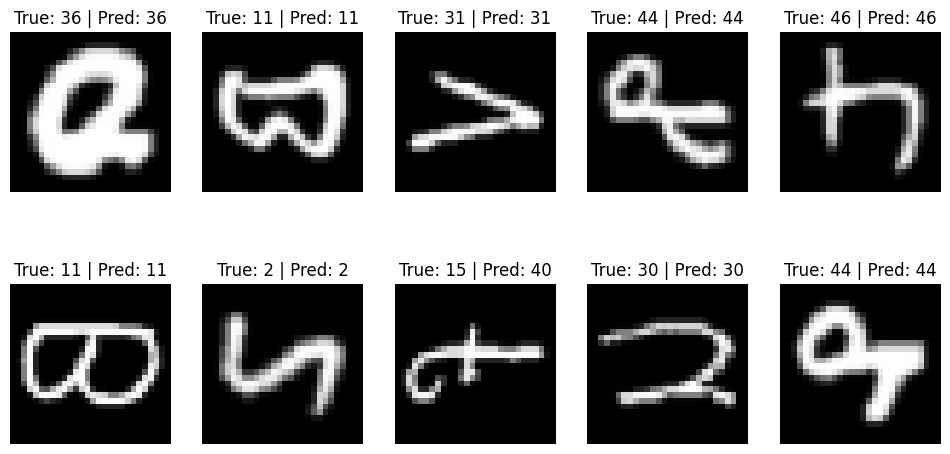

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

(ds_train, ds_test), ds_info = tfds.load(
    'emnist/balanced',
    split=['train', 'test'],
    shuffle_files=True,
    as_supervised=True,
    with_info=True
)

def normalize_img(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.reshape(image, [-1])
    return image, label

batch_size = 128
ds_train = ds_train.map(normalize_img).cache().shuffle(1000).batch(batch_size).prefetch(tf.data.AUTOTUNE)
ds_test = ds_test.map(normalize_img).batch(batch_size).cache().prefetch(tf.data.AUTOTUNE)

num_classes = ds_info.features['label'].num_classes

model = models.Sequential([
    layers.Input(shape=(28*28,)),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()
history = model.fit(ds_train, epochs=10, validation_data=ds_test)
test_loss, test_acc = model.evaluate(ds_test)
print(f"Test Accuracy: {test_acc*100:.2f}%")

import numpy as np

for images, labels in ds_test.take(1):
    preds = model.predict(images)
    preds_cls = np.argmax(preds, axis=1)

    plt.figure(figsize=(12, 6))
    for i in range(10):
        plt.subplot(2, 5, i+1)
        plt.imshow(tf.reshape(images[i], (28, 28)), cmap='gray')
        plt.title(f"True: {labels[i].numpy()} | Pred: {preds_cls[i]}")
        plt.axis('off')
    plt.show()